# Time series forecasting for beehive monitoring

This notebook uses the **BeeObserver (BoB)** dataset - sensor data from instrumented honey bee colonies recorded across apiaries in Germany between 2019 and 2022.

The real deployment uses two sensor units:
- **Outside unit** - temperature (DS18B20)
- **Inside unit** - temperature, humidity, and pressure (BME280)

The BoB dataset provides equivalent signals (`t_o`, `h`, `t`, `p`, `t_i_*`) alongside hive weight, making it a suitable stand-in for model development and evaluation.

**Forecasting targets:**
- `weight_delta_noOutlier` - hourly hive weight change (kg/h), primary target
- `t_i_3` - central internal hive temperature (°C), secondary target (health indicator)

**Feature channels:**
- `t_o` - outside temperature
- `h` - inside humidity
- `p` - inside pressure

**Models:**
- **LightGBM** - gradient-boosted trees with lag features, separate model per target
- **LSTM** - small recurrent neural network, multi-input multi-output, trained as a comparison point

**Anomaly detection** is applied on top of both models using residual-based flagging.

Dataset source: [BeeObserver on Zenodo](https://zenodo.org/records/10407693)

## 1. Libraries and dependencies

- `pandas` / `numpy` - data loading, manipulation, and numerical operations
- `matplotlib` / `seaborn` - visualisation
- `statsmodels` - time series diagnostics (ADF test, ACF/PACF, seasonal decomposition)
- `lightgbm` - gradient boosted trees for multivariate forecasting
- `scikit-learn` - metrics and preprocessing
- `torch` - LSTM model

> **Installation:** `%pip install statsmodels lightgbm scikit-learn torch`

In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
import os
import pickle

# Core
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Time series diagnostics
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

# LightGBM
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

# LSTM
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

# Plot style
sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

print(f'LightGBM version : {lgb.__version__}')
print(f'PyTorch version  : {torch.__version__}')

LightGBM version : 4.6.0
PyTorch version  : 2.11.0+cpu


## 2. Load data

Dataset contains raw and processed data that are grouped by years, inspections and events. This project will be using processed data by years. 

Every colony has its own unique key and separate file for each year (if data exists). Each column contains minute-resolution sensor reading and other computed and anotated metrics from those values (weight delta, event, ...).

| Column | Unit | Description |
|---|---|---|
| `weight_kg_noOutlier` | kg | Hive weight (outlier-corrected) |
| `weight_delta_noOutlier` | kg/h | Weight change - **primary forecast target** |
| `t_o` | °C | Outside temperature |
| `h` | % | Outside relative humidity |
| `t_i_3` | °C | Internal temperature, centre frame - **secondary target** |
| `t` | °C | Internal temperature |
| `p` | hPa | Internal air pressure |
| `t_i_1..5` | °C | Internal hive temperatures at 5 frame positions|

> See the dataset's `readme.txt` for full column descriptions.

In [ ]:
BASE_PATH = 'data/BeeObserver'
DATA_YEAR = '2020'
DATA_KEY = '49'
DATA_YEARS = ['2019', '2020', '2021', '2022']

df = pd.read_csv(f'{BASE_PATH}/{DATA_YEAR}/{DATA_KEY}.csv', parse_dates = ['time'], index_col = 'time', low_memory = False)
df = df.sort_index()

print(f'Shape: {df.shape}')
print(f'Date range: {df.index.min()} → {df.index.max()}')
print(f'\nColumn list:\n{df.columns.tolist()}')

SENSOR_COLS = ['weight_kg_noOutlier', 'weight_delta_noOutlier', 't_o', 'h', 't_i_3', 'p']

Shape: (8120, 54)
Date range: 2020-01-01 00:00:00 → 2020-12-31 23:00:00

Column list:
['Unnamed: 0', 'X.1', 'X', 't_i_1', 't_i_2', 't_i_3', 't_i_4', 't_i_5', 't_o', 'weight_kg', 'h', 't', 'p', 'key', 'day', 'month', 'year', 'hour', 'minute', 'second', 'uni_time', 'numeric.time', 'weight_delta', 'no_jump', 'outlier_lim', 'weight_delta_noOutlier', 'weight_kg_noOutlier', 'with_0', 'queencell.last', 'queencell.next', 'queencell.last.dif', 'queencell.next.dif', 'feeding.last', 'feeding.next', 'feeding.last.dif', 'feeding.next.dif', 'honey.last', 'honey.next', 'honey.last.dif', 'honey.next.dif', 'treatment.last', 'treatment.next', 'treatment.last.dif', 'treatment.next.dif', 'died.last', 'died.next', 'died.last.dif', 'died.next.dif', 'swarming.last', 'swarming.next', 'swarming.last.dif', 'swarming.next.dif', 'lon', 'lat']


## 3. Data visualisation

The plots below show all key variables for the selected colony and year:
1. **Hive weight** - shows the seasonal nectar flow (rising weight in spring/summer), feeding events (sharp increases), and honey harvest (sharp drops)
2. **Weight change (Δ weight)** - primary forecast target, noisy around zero with event spikes
3. **Outside temperature** - strongly seasonal and expected to correlate with bee activity and weight change
4. **Internal humidity** - secondary environmental context
5. **Internal temperature (centre frame)** - healthy brood cluster holds 34–36 °C, deviations are early health signals
6. **Internal pressure** - proxy for ventilation and hive sealing

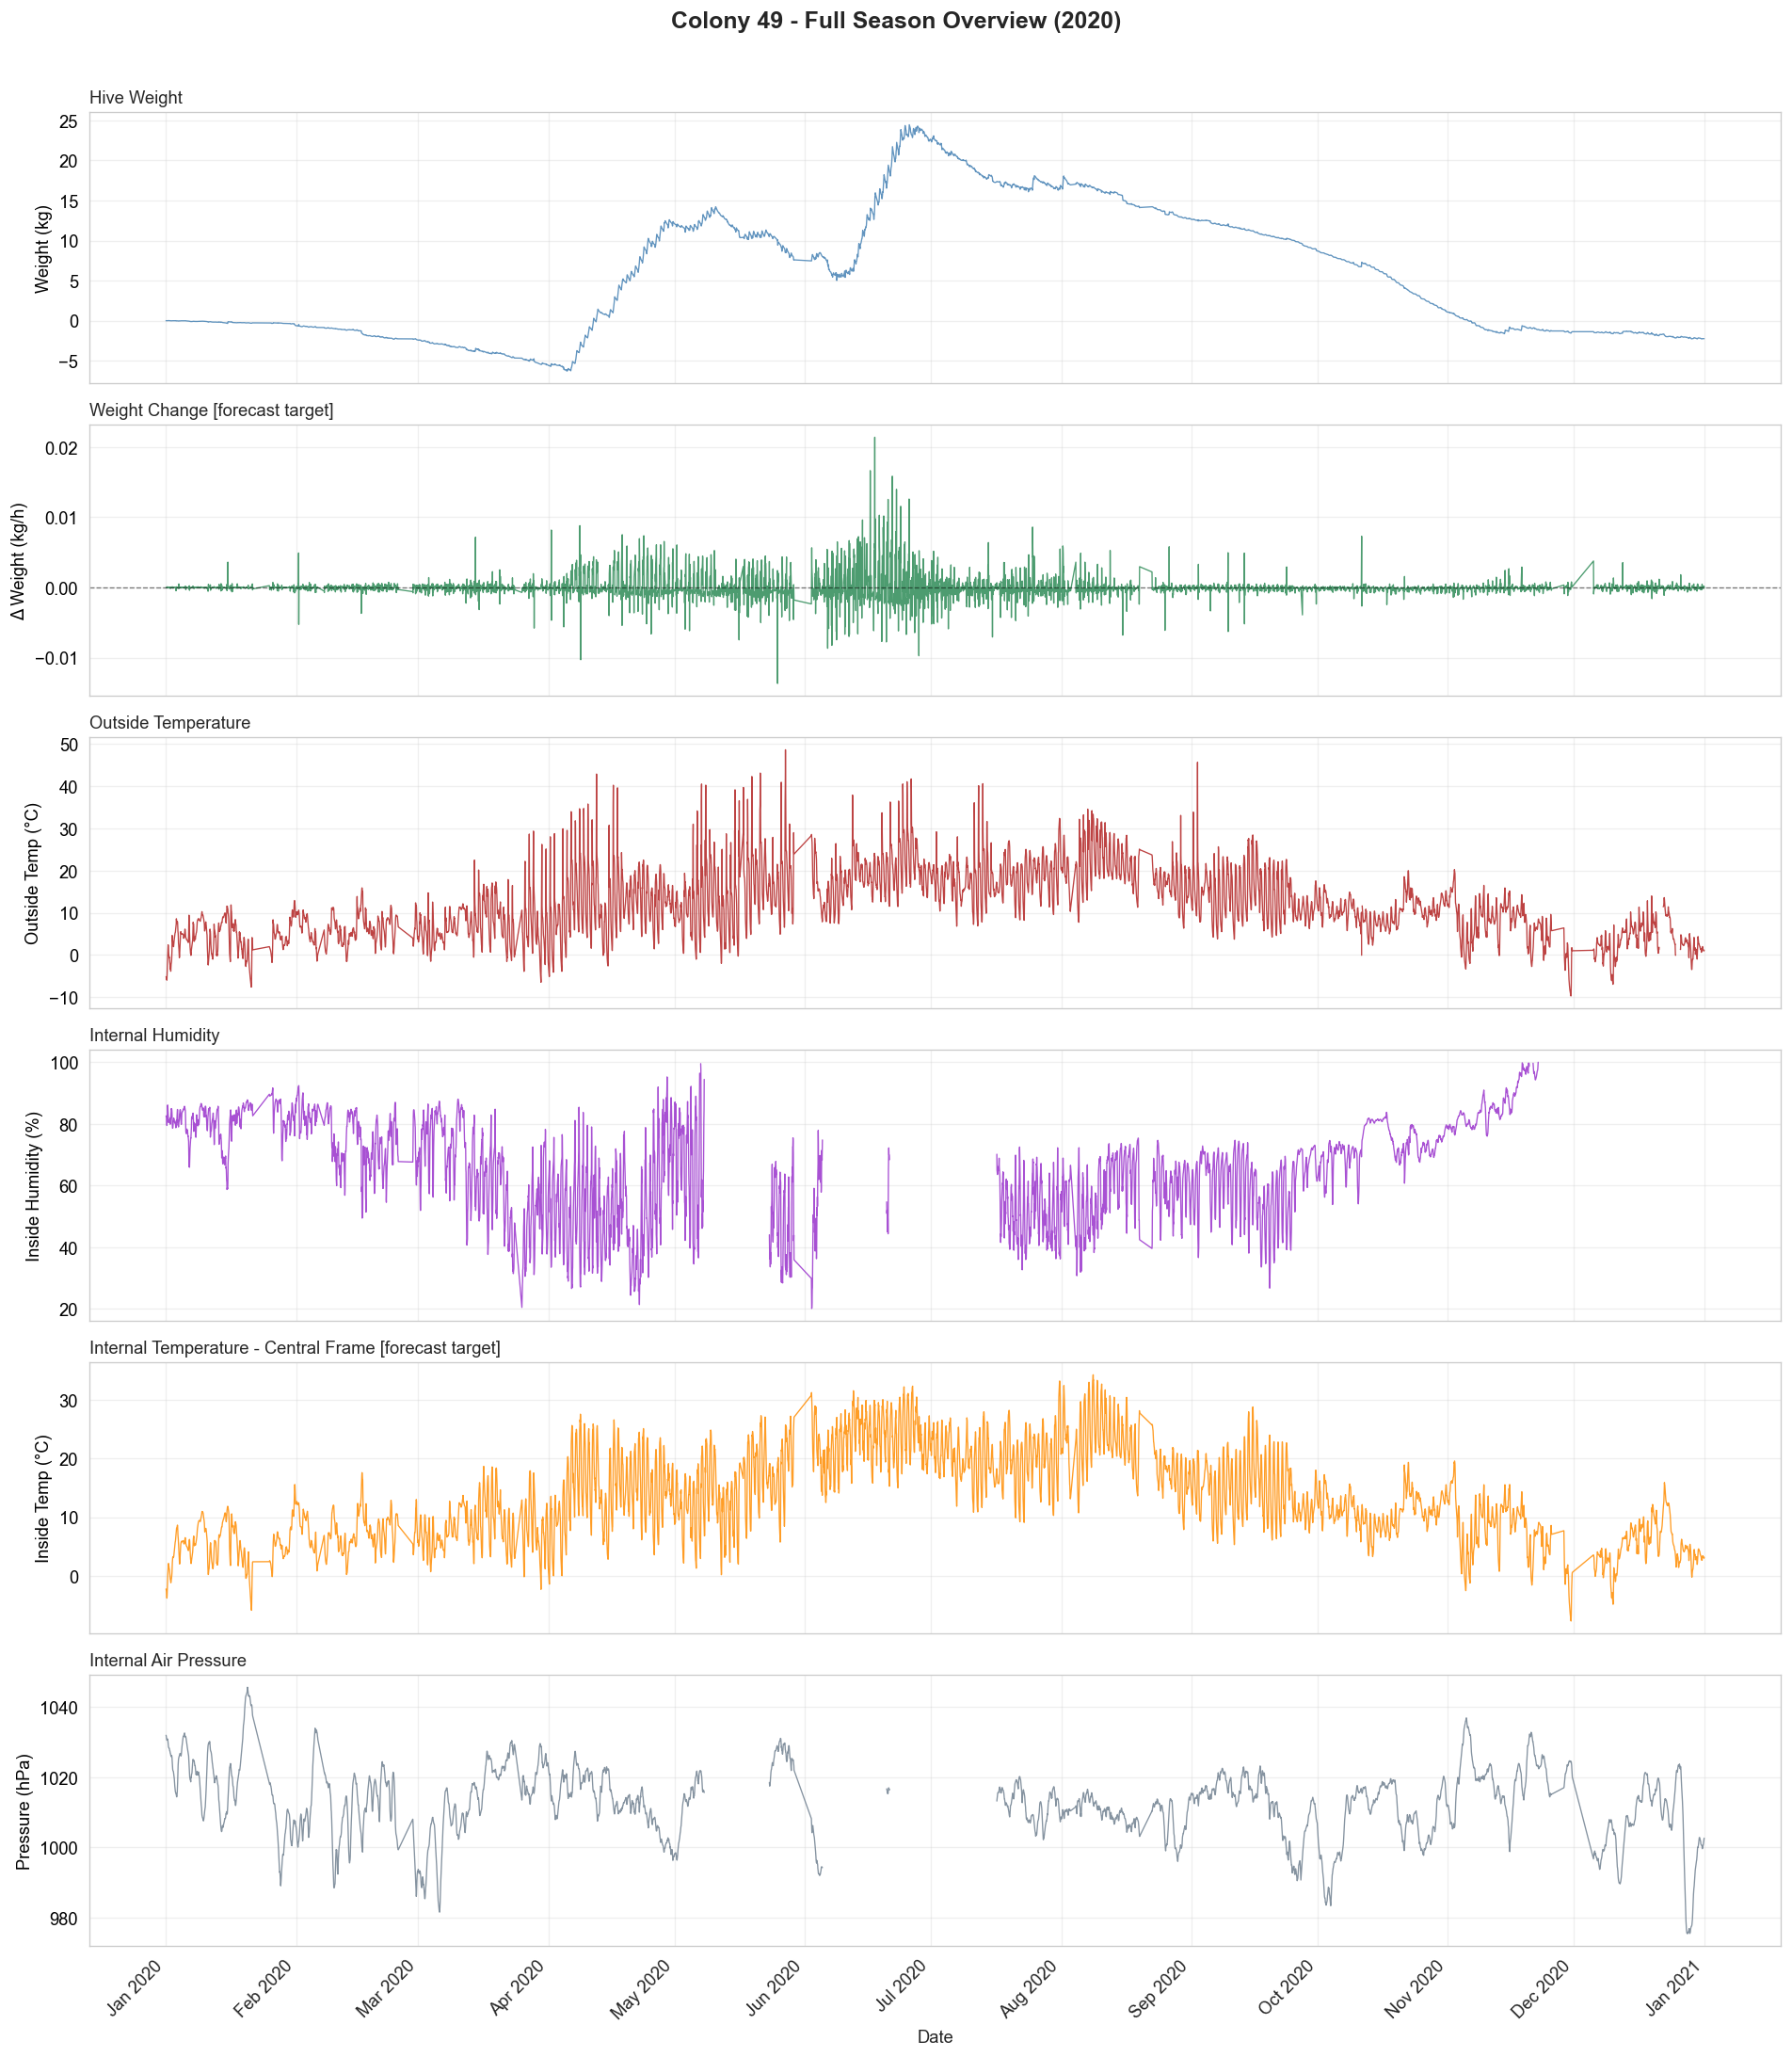

In [16]:
fig, axes = plt.subplots(6, 1, figsize = (16, 18), sharex = True)
fig.suptitle(f'Colony {DATA_KEY} - Full Season Overview ({DATA_YEAR})', fontsize=15, fontweight='bold', y = 1.01)

panels = [
    ('weight_kg_noOutlier', 'Weight (kg)', 'steelblue', 'Hive Weight'),
    ('weight_delta_noOutlier', 'Δ Weight (kg/h)', 'seagreen', 'Weight Change [forecast target]'),
    ('t_o', 'Outside Temp (°C)', 'firebrick', 'Outside Temperature'),
    ('h', 'Inside Humidity (%)','darkorchid', 'Internal Humidity'),
    ('t_i_3', 'Inside Temp (°C)', 'darkorange', 'Internal Temperature - Central Frame [forecast target]'),
    ('p', 'Pressure (hPa)', 'slategrey', 'Internal Air Pressure'),
]

for ax, (col, ylabel, color, title) in zip(axes, panels):
    if col not in df.columns:
        ax.text(0.5, 0.5, f'{col} not available', transform=ax.transAxes, ha='center')
        continue
    ax.plot(df.index, df[col], linewidth=0.8, color=color, alpha=0.85)
    if col == 'weight_delta_noOutlier':
        ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.set_ylabel(ylabel, color='black')
    ax.tick_params(axis='y', labelcolor='black')
    ax.set_title(title, loc='left', fontsize=11)
    ax.grid(True, alpha=0.3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
axes[-1].set_xlabel('Date')
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

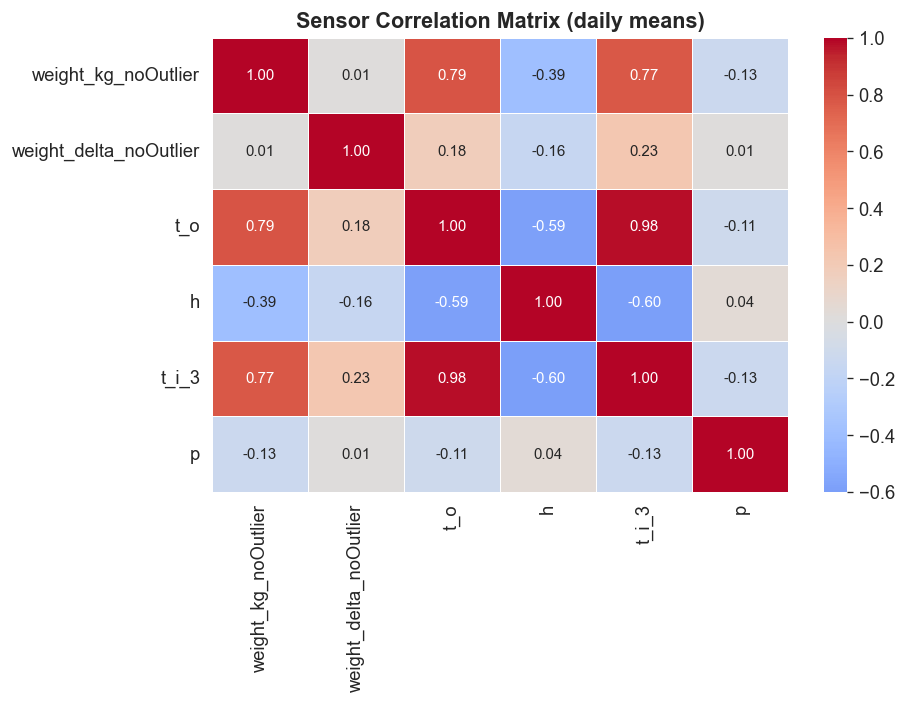

In [ ]:
# Correlation matrix across all sensor channels
corr_cols = [c for c in SENSOR_COLS if c in df.columns]
corr = df[corr_cols].resample('D').mean().corr().round(2)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5, ax=ax, annot_kws={'size': 9}
)
ax.set_title('Sensor Correlation Matrix (daily means)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Data preparation and cleaning
This dataset already contains cleaned and preprocessed data (outlier-removed weight deltas, calibrated sensors). There are 78 colonies available across the four years, but not all colonies have complete data for all years.

The plan is to:
1. Find and load data for colony across all available years and minimal missing values. Concatenate into a sigle dataframe
2. Apply light cleaning - drop fully-empty rows, interpolate short temperature/humidity gaps
3. Add lag features for LightDBM - past values of all sensor channels at selected offsets
4. Train/Test split

In [ ]:
def load_hive_year(year: str, hive_key: str) -> pd.DataFrame:
    """Load one year of hourly preprocessed data for a single colony."""
    file_path = f'{BASE_PATH}/{year}/{hive_key}.csv'
    df = pd.read_csv(file_path, parse_dates = ['time'], index_col = 'time', low_memory = False)
    df = df.sort_index()
    keep = ['weight_kg_noOutlier', 'weight_delta_noOutlier', 't_o', 'h', 't_i_3', 'p']
    return df[[c for c in keep if c in df.columns]]

### 4.1 Concatenate data from available years

In [15]:
dfs = []
for year in DATA_YEARS:
    try:
        df_year = load_hive_year(year, DATA_KEY)
        dfs.append(df_year)
        print(f'Loaded colony {DATA_KEY} - {year}: {df_year.shape}')
    except FileNotFoundError:
        print(f'[SKIP] No data for colony {DATA_KEY} in {year}')

df_all = pd.concat(dfs).sort_index()
print('Combined shape:', df_all.shape)
print('Date range:', df_all.index.min(), '->', df_all.index.max())

Loaded colony 49 - 2019: (2664, 6)
Loaded colony 49 - 2020: (8120, 6)
Loaded colony 49 - 2021: (6529, 6)
Loaded colony 49 - 2022: (6650, 6)
Combined shape: (23963, 6)
Date range: 2019-08-25 00:00:00 -> 2022-12-31 23:00:00


### 4.2 Handle rows with missing values

In [17]:
# Drop empty rows (or NaN)
df_all = df_all.dropna(how = 'all')

# Sensor range filters
df_all.loc[(df_all['t_o'] < -40) | (df_all['t_o'] > 80), 't_o'] = np.nan
if 't_i_3' in df_all.columns:
    df_all.loc[(df_all['t_i_3'] < -10) | (df_all['t_i_3'] > 50), 't_i_3'] = np.nan
if 'p' in df_all.columns:
    df_all.loc[(df_all['p'] < 900) | (df_all['p'] > 1100), 'p'] = np.nan

# Linear interpolation for short gaps
for col in ['t_o', 'h', 't_i_3', 'p']:
    if col in df_all.columns:
        df_all[col] = df_all[col].interpolate(method='linear', limit=3, limit_direction='both')

print('NaN fraction per column (after cleaning):')
print(df_all.isnull().mean().round(4))

NaN fraction per column (after cleaning):
weight_kg_noOutlier       0.0000
weight_delta_noOutlier    0.0001
t_o                       0.3583
h                         0.4312
t_i_3                     0.3719
p                         0.3793
dtype: float64


### 4.3 Add lag features for LightDBM

LightGBM has no built-in notion of time ordering - it treats each row as an independent observation. To give the model access to the history of each signal, create **lag features**: the value of each sensor column at *t−k* hours for a set of offsets *k*.

Selected lags:
- **Short-term** (1–6 h) - capture intra-day momentum
- **Daily** (24 h) - same hour yesterday
- **Two-day / weekly** (48, 168 h) - medium and long-range seasonal patterns

Add **datetime features** (hour of day, day of week, month) and **Fourier encodings** of daily and yearly cycles so the model can learn time-of-day and seasonal patterns directly.

Add **rolling statistics** (24 h and 168 h windows) to give the model a compact summary of recent signal behaviour.

In [ ]:
LAG_COLS = ['weight_delta_noOutlier', 't_o', 'h', 't_i_3', 'p']
LAGS = [1, 2, 3, 6, 12, 24, 48, 168]#, 4380, 8760]

df_feat = df_all.copy()

for col in LAG_COLS:
    if col not in df_feat.columns:
        continue
    for lag in LAGS:
        df_feat[f'{col}_lag{lag}'] = df_feat[col].shift(lag)

# Datetime features
df_feat['hour'] = df_feat.index.hour
df_feat['dayofweek'] = df_feat.index.dayofweek
df_feat['month'] = df_feat.index.month

# Fourier features - daily cycle
df_feat['hour_sin'] = np.sin(2 * np.pi * df_feat.index.hour / 24)
df_feat['hour_cos'] = np.cos(2 * np.pi * df_feat.index.hour / 24)

# Fourier features - yearly cycle
df_feat['day_sin'] = np.sin(2 * np.pi * df_feat.index.dayofyear / 365)
df_feat['day_cos'] = np.cos(2 * np.pi * df_feat.index.dayofyear / 365)

# Rolling statistics - shift(1) before rolling to avoid data leakage
for col in LAG_COLS:
    if col not in df_feat.columns:
        continue
    df_feat[f'{col}_roll24_mean'] = df_feat[col].shift(1).rolling(24).mean()
    df_feat[f'{col}_roll24_std'] = df_feat[col].shift(1).rolling(24).std()
    df_feat[f'{col}_roll168_mean'] = df_feat[col].shift(1).rolling(168).mean()
    df_feat[f'{col}_roll168_std'] = df_feat[col].shift(1).rolling(168).std()

# Drop rows with NaNs introduced by lagging and rolling
df_feat = df_feat.dropna()

print(f'Feature matrix shape : {df_feat.shape}')
print(f'Date range           : {df_feat.index.min()} → {df_feat.index.max()}')
print(f'Total features       : {len(df_feat.columns)}')

Feature matrix shape : (7954, 73)
Date range           : 2019-09-05 11:00:00 → 2021-09-10 10:00:00
Total features       : 73


## 5. Train / test split

A **chronological 80/20 split** is used - first 80% of the timestamps form a training set and the remaining 20% the test set.

In [19]:
split_idx = int(len(df_feat) * 0.80)
df_train = df_feat.iloc[:split_idx].copy()
df_test = df_feat.iloc[split_idx:].copy()

print(f'Train: {df_train.index.min()} -> {df_train.index.max()} | {df_train.shape}')
print(f'Test:  {df_test.index.min()} -> {df_test.index.max()} | {df_test.shape}')

Train: 2019-09-05 11:00:00 -> 2020-09-18 16:00:00 | (6363, 73)
Test:  2020-09-18 17:00:00 -> 2021-09-10 10:00:00 | (1591, 73)


## 6. Shared evaluation and anomaly detection helpers

Three standard metrics are used to quantify forecast accuracy:

| Metric | Formula | Interpretation |
|---|---|---|
| **MAE** | mean(\|y − ŷ\|) | Average absolute error - same units as target (kg) |
| **RMSE** | √mean((y − ŷ)²) | Root Mean Squared Error - penalizes large errors more heavily than MAE |
| **MAPE** | mean(\|y − ŷ\| / \|y\|) × 100 | Mean absolute percentage error - useful for comparing across scales |

In [20]:
def eval_metrics(actual, predicted, model_name, target_name):
    actual = np.array(actual)
    predicted = np.array(predicted)
    mask = actual != 0

    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100 if mask.sum() > 0 else np.nan

    unit = 'kg/h' if 'weight' in target_name else '°C'
    print(f'  {target_name}:')
    print(f'    MAE  : {mae:.6f} {unit}')
    print(f'    RMSE : {rmse:.6f} {unit}')
    print(f'    MAPE : {mape:.2f}% (over {mask.sum()} non-zero points)')

    return {'model': model_name, 'target': target_name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

Anomaly detection is residual-based - a timestep is flagged as anomalous when the absolute difference between the actual and predicted value exceeds a threshold of ±3 standard deviations of the residuals.

In [21]:
def detect_anomalies(actual, predicted, model_name, target_name, threshold_std=3.0):
    """Flag timesteps where residual exceeds threshold_std standard deviations."""
    residuals = actual - predicted
    mean, std = residuals.mean(), residuals.std()
    anomalies = residuals[np.abs(residuals - mean) > threshold_std * std]
    print(f'  {model_name} / {target_name}: {len(anomalies)} anomalies '
          f'({100 * len(anomalies) / len(residuals):.2f}% of test set, threshold ±{threshold_std}σ)')
    return anomalies

def plot_anomalies(weight_series, temp_series, anomaly_dict, title):
    """Overlay anomaly markers on hive weight and inside temperature in one figure."""
    fig, ax1 = plt.subplots(figsize=(16, 5))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    colors = ['red', 'darkorange', 'seagreen', 'purple', 'brown']
    markers = ['o', 'x', '^', 's', 'D']

    # Primary axis - hive weight
    ax1.plot(weight_series.index, weight_series.values,
             color='steelblue', linewidth=0.8, alpha=0.85, label='Hive weight (kg)')
    ax1.set_ylabel('Weight (kg)', color='black')
    ax1.tick_params(axis='y', labelcolor='black')

    # Secondary axis - inside temperature
    ax2 = ax1.twinx()
    ax2.plot(temp_series.index, temp_series.values,
             color='darkorange', linewidth=0.8, alpha=0.6, label='Inside temp (°C)')
    ax2.set_ylabel('Inside Temp (°C)', color='black')
    ax2.tick_params(axis='y', labelcolor='black')

    # Anomaly markers on both axes
    for (label, anomalies), color, marker in zip(anomaly_dict.items(), colors, markers):
        w_idx = anomalies.index.intersection(weight_series.index)
        ax1.scatter(w_idx, weight_series.reindex(w_idx),
                    color=color, s=40, marker=marker, zorder=5, alpha=0.8, label=label)

    # Combined legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper left')

    ax1.set_xlabel('Date')
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax1.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax1.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## 7. LightGBM

Two separate LightGBM models are trained - one per target - using the full lag feature matrix from section 4.3.

### 7.1 Separate models (one per target)

In [22]:
TARGETS = ['weight_delta_noOutlier', 't_i_3']
feature_cols = [c for c in df_feat.columns if c not in TARGETS]

X_train_lgb = df_train[feature_cols]
X_test_lgb = df_test[feature_cols]

print(f'Features : {len(feature_cols)}')
print(f'Train    : {X_train_lgb.shape} | Test: {X_test_lgb.shape}')

Features : 71
Train    : (6363, 71) | Test: (1591, 71)


In [23]:
lgb_single_models = {}
lgb_single_preds = {}
lgb_single_metrics = []

# Target-specific parameters
params_per_target = {
    'weight_delta_noOutlier': {
        'objective'        : 'regression',
        'metric'           : 'rmse',
        'learning_rate'    : 0.05,
        'num_leaves'       : 31,
        'min_data_in_leaf' : 30,
        'feature_fraction' : 0.7,
        'bagging_fraction' : 0.7,
        'bagging_freq'     : 5,
        'lambda_l1'        : 0.1,
        'lambda_l2'        : 0.1,
        'verbose'          : -1,
        'seed'             : 42,
    },
    't_i_3': {
        'objective'        : 'regression',
        'metric'           : 'rmse',
        'learning_rate'    : 0.05,
        'num_leaves'       : 64,
        'min_data_in_leaf' : 20,
        'feature_fraction' : 0.8,
        'bagging_fraction' : 0.8,
        'bagging_freq'     : 5,
        'lambda_l1'        : 0.01,
        'lambda_l2'        : 0.01,
        'verbose'          : -1,
        'seed'             : 42,
    },
}

for target in TARGETS:
    y_tr = df_train[target]
    y_te = df_test[target]

    d_train = lgb.Dataset(X_train_lgb, label=y_tr)
    d_val = lgb.Dataset(X_test_lgb, label=y_te, reference=d_train)

    model = lgb.train(
        params_per_target[target],
        d_train,
        num_boost_round = 1000,
        valid_sets = [d_val],
        callbacks = [lgb.early_stopping(50, verbose=False), lgb.log_evaluation(200)],
    )
    pred = pd.Series(model.predict(X_test_lgb), index=y_te.index)

    lgb_single_models[target] = model
    lgb_single_preds[target] = pred

    print(f'\n=== LightGBM (separate) - {target} ===')
    m = eval_metrics(y_te, pred, 'LightGBM-separate', target)
    lgb_single_metrics.append(m)


=== LightGBM (separate) - weight_delta_noOutlier ===
  weight_delta_noOutlier:
    MAE  : 0.000244 kg/h
    RMSE : 0.000628 kg/h
    MAPE : 297.44% (over 1591 non-zero points)

=== LightGBM (separate) - t_i_3 ===
  t_i_3:
    MAE  : 0.559371 °C
    RMSE : 0.728883 °C
    MAPE : 10.79% (over 1591 non-zero points)


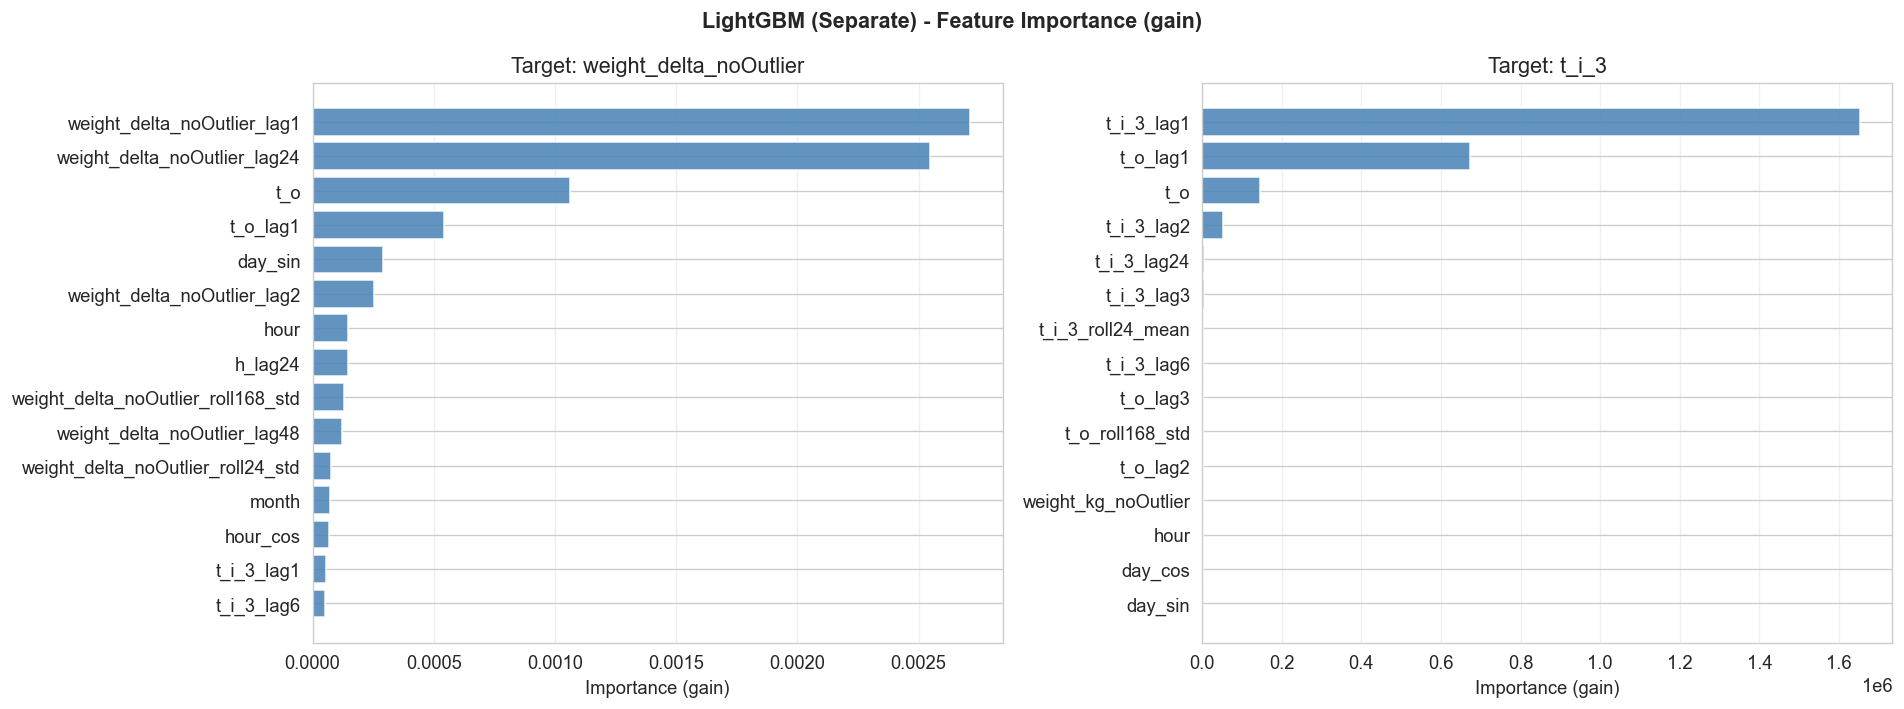

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('LightGBM (Separate) - Feature Importance (gain)', fontsize=13, fontweight='bold')

for ax, target in zip(axes, TARGETS):
    imp = pd.DataFrame({
        'feature' : lgb_single_models[target].feature_name(),
        'importance' : lgb_single_models[target].feature_importance(importance_type='gain'),
    }).sort_values('importance', ascending=False).head(15)

    ax.barh(imp['feature'][::-1], imp['importance'][::-1], color='steelblue', alpha=0.85)
    ax.set_title(f'Target: {target}')
    ax.set_xlabel('Importance (gain)')
    ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

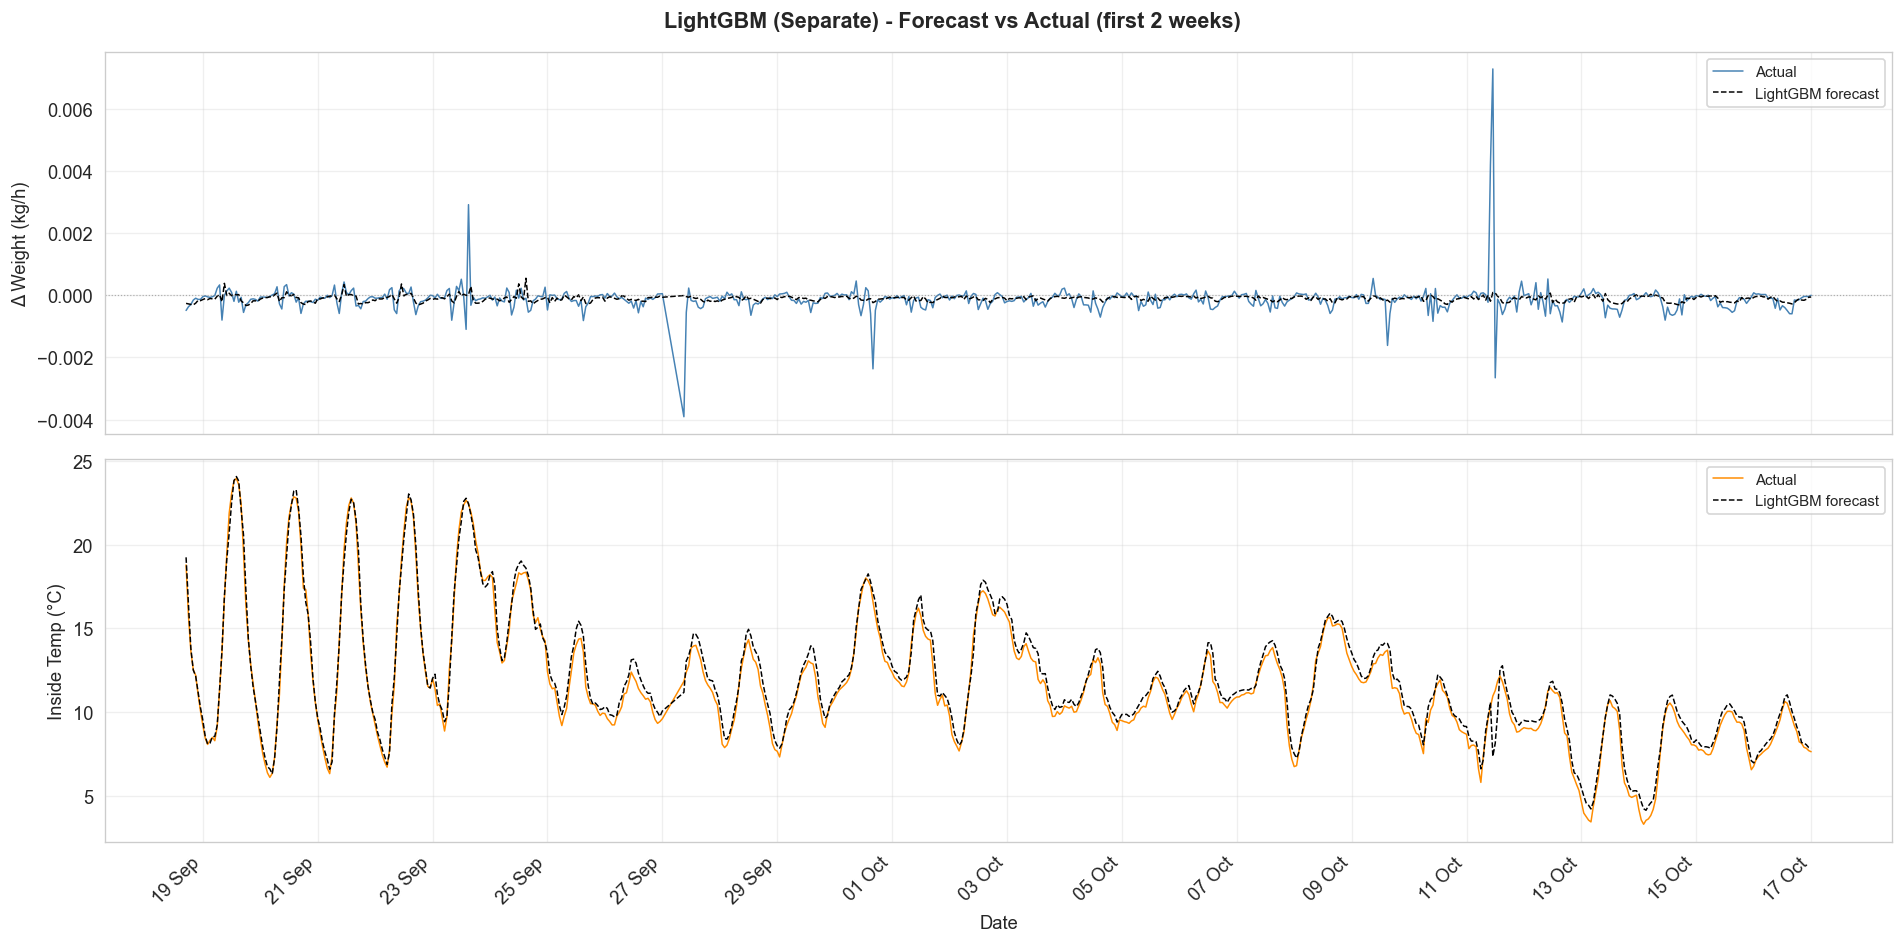

In [25]:
sample = 24 * 14 * 2
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
fig.suptitle('LightGBM (Separate) - Forecast vs Actual (first 2 weeks)', fontsize=13, fontweight='bold')

plot_cfg = [
    ('weight_delta_noOutlier', 'Δ Weight (kg/h)', 'steelblue'),
    ('t_i_3', 'Inside Temp (°C)', 'darkorange'),
]
for ax, (col, ylabel, color) in zip(axes, plot_cfg):
    actual = df_test[col]
    pred = lgb_single_preds[col]
    ax.plot(actual.index[:sample], actual.iloc[:sample], color=color, linewidth=0.9, label='Actual')
    ax.plot(pred.index[:sample], pred.iloc[:sample], color='black', linewidth=0.9, linestyle='--', label='LightGBM forecast')
    if col == 'weight_delta_noOutlier':
        ax.axhline(0, color='grey', linestyle=':', linewidth=0.7, alpha=0.6)
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
axes[1].xaxis.set_major_locator(mdates.DayLocator(interval=2))
axes[1].set_xlabel('Date')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 8.2 Anomaly detection

LightGBM anomalies:
  LightGBM / weight_delta_noOutlier: 23 anomalies (1.45% of test set, threshold ±3.0σ)
  LightGBM / t_i_3: 27 anomalies (1.70% of test set, threshold ±3.0σ)


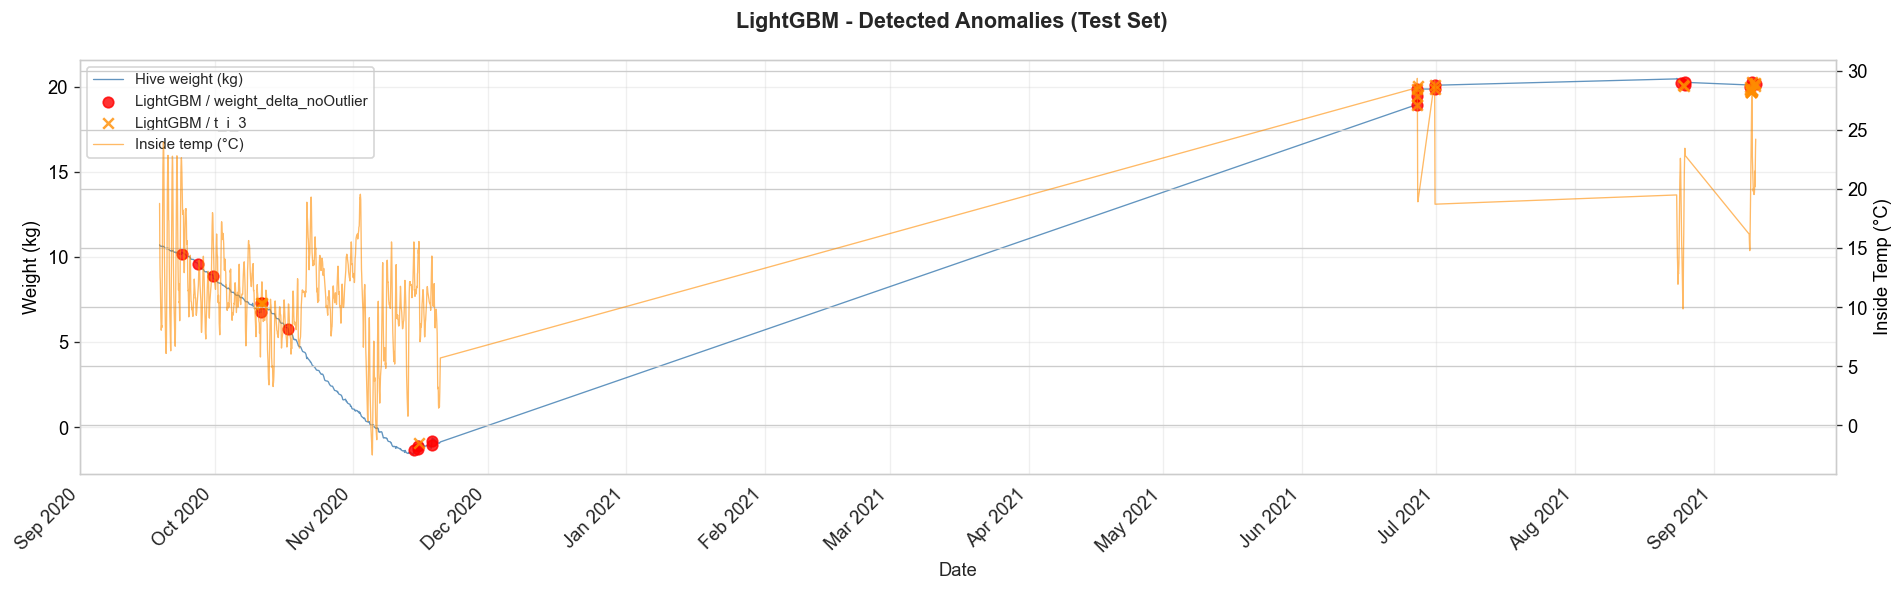

In [26]:
weight_test_lgb = df_feat['weight_kg_noOutlier'].reindex(df_test.index)
temp_test_lgb = df_feat['t_i_3'].reindex(df_test.index)

print('LightGBM anomalies:')
lgb_sep_anom = {}
for col in TARGETS:
    anom = detect_anomalies(df_test[col], lgb_single_preds[col], 'LightGBM', col)
    lgb_sep_anom[f'LightGBM / {col}'] = anom

plot_anomalies(weight_test_lgb, temp_test_lgb, lgb_sep_anom, 'LightGBM - Detected Anomalies (Test Set)')

### 7.3 Save models for deployment

In [27]:
# Save separate models
for target, model in lgb_single_models.items():
    fname = f'lgb_separate_{target.replace("_", "-")}.txt'
    model.save_model(fname)
    print(f'Saved: {fname} ({os.path.getsize(fname)/1024:.1f} KB)')

# Save feature column list -- required by forecast_anomaly_detection.py
with open('lgb_feature_cols.json', 'w') as f:
    json.dump(feature_cols, f)
print('Saved: lgb_feature_cols.json')

Saved: lgb_separate_weight-delta-noOutlier.txt (98.6 KB)
Saved: lgb_separate_t-i-3.txt (488.6 KB)
Saved: lgb_feature_cols.json


## 8. LSTM

A small **Long Short-Term Memory** (LSTM) network is trained to predict both targets simultaneously from all sensor channels. Unlike LightGBM, the LSTM processes sequences of past observations directly - it learns temporal dependencies across the full input history without requiring manual lag feature engineering.

**Architecture:**
- Input: sliding window of the last **168 hours** (one full week × all sensor channels)
- Two LSTM layers (64 hidden units each) with dropout (0.3) for regularisation
- Two-layer dense head predicting both `weight_delta_noOutlier` and `t_i_3` simultaneously

**Training configuration:**
- Optimiser: Adam with learning rate 5×10⁻⁴ and weight decay 10⁻⁴
- Loss: Mean Squared Error (MSE)
- Early stopping: patience 30 epochs, restores best weights
- LR scheduler: ReduceLROnPlateau (patience 5, factor 0.5)

### 8.1 Prepare sequences

The LSTM operates on **sliding window sequences** of length 168 hours. Each sequence contains the raw sensor readings for the preceding week, and the label is the value at the next timestep. All features and targets are scaled with `StandardScaler` before training and inverse-transformed after prediction to recover original units.

Note that the LSTM uses `df_all` directly - the raw sensor columns without the lag feature engineering used for LightGBM. The temporal context is provided implicitly through the sequence window instead.

In [28]:
SEQUENCE_LEN = 168 # look-back window in hours (1 week)
LSTM_FEATURES = [c for c in df_all.columns if c != ['weight_kg_noOutlier', 't']]
LSTM_TARGETS = ['weight_delta_noOutlier', 't_i_3']

# df_all - LSTM handles its own temporal context via sequences
df_lstm = df_all[LSTM_FEATURES].dropna().copy()

# Scale features and targets separately
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(df_lstm[LSTM_FEATURES])
y_scaled = scaler_y.fit_transform(df_lstm[LSTM_TARGETS])

def make_sequences(X, y, seq_len):
    """Create sliding window sequences for LSTM input."""
    Xs, ys = [], []
    for i in range(seq_len, len(X)):
        Xs.append(X[i - seq_len:i])
        ys.append(y[i])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)

X_seq, y_seq = make_sequences(X_scaled, y_scaled, SEQUENCE_LEN)

# Chronological 80/20 split
split_seq = int(len(X_seq) * 0.80)
X_tr, X_te = X_seq[:split_seq], X_seq[split_seq:]
y_tr, y_te = y_seq[:split_seq], y_seq[split_seq:]

# Timestamps for aligning predictions later
lstm_test_idx = df_lstm.index[SEQUENCE_LEN + split_seq:]

print(f'Train sequences : {X_tr.shape}')
print(f'Test sequences  : {X_te.shape}')
print(f'Input features  : {len(LSTM_FEATURES)}')
print(f'Features used   : {LSTM_FEATURES}')

# PyTorch datasets and loaders
train_dataset = TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr))
test_dataset = TensorDataset(torch.from_numpy(X_te), torch.from_numpy(y_te))

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

Train sequences : (8349, 168, 6)
Test sequences  : (2088, 168, 6)
Input features  : 6
Features used   : ['weight_kg_noOutlier', 'weight_delta_noOutlier', 't_o', 'h', 't_i_3', 'p']


### 8.2 Build model

The `BeehiveLSTM` class defines a two-layer stacked LSTM followed by a two-layer dense head. The final LSTM layer's output at the **last timestep** is passed to the dense head - this is the standard approach for sequence-to-one prediction where a single vector summarises the entire input window.

Dropout (0.3) is applied between LSTM layers to reduce overfitting. The dense head uses a ReLU activation and outputs two values simultaneously - one per forecast target.

In [29]:
class BeehiveLSTM(nn.Module):
    """Two-layer LSTM with dropout, predicting both weight delta and inside temperature."""
    def __init__(self, input_size, hidden_size=64, num_layers=2, output_size=2, dropout=0.2):
        super(BeehiveLSTM, self).__init__()
        self.lstm = nn.LSTM(
            input_size = input_size,
            hidden_size = hidden_size,
            num_layers = num_layers,
            batch_first = True,
            dropout = dropout,
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Linear(32, output_size),
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        return self.fc(lstm_out[:, -1, :])   # use last timestep output

model = BeehiveLSTM(
    input_size = len(LSTM_FEATURES),
    hidden_size = 64,
    num_layers = 2,
    output_size = len(LSTM_TARGETS),
    dropout = 0.3,
).to(torch.device('cpu'))

print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'\nTotal parameters: {total_params:,}')

BeehiveLSTM(
  (lstm): LSTM(6, 64, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=2, bias=True)
  )
)

Total parameters: 53,858


### 8.3 Train model

Training uses **early stopping** with patience 30 - the loop stops when validation loss has not improved for 30 consecutive epochs, and the best weights are restored automatically. The `ReduceLROnPlateau` scheduler halves the learning rate when validation loss plateaus, allowing finer convergence in later epochs.

The train/validation loss gap observed during experiments reflects the fundamental challenge of single-colony, limited-duration data - the model has enough capacity to memorise training patterns but insufficient diversity to fully generalise. This is the primary motivation for preferring LightGBM for deployment.

In [30]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
device = torch.device('cpu')

N_EPOCHS = 150
PATIENCE = 30
best_val_loss = float('inf')
patience_count = 0
train_losses = []
val_losses = []

for epoch in range(N_EPOCHS):
    # --- Training ---
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(X_batch)
    train_loss /= len(train_dataset)

    # --- Validation ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            pred = model(X_batch)
            val_loss += criterion(pred, y_batch).item() * len(X_batch)
    val_loss /= len(test_dataset)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:3d}/{N_EPOCHS} - train loss: {train_loss:.6f} val loss: {val_loss:.6f}')

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'lstm_best_weights.pt')
        patience_count = 0
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f'\nEarly stopping at epoch {epoch+1}')
            break

# Restore best weights
model.load_state_dict(torch.load('lstm_best_weights.pt', map_location=device))
print(f'\nBest validation loss: {best_val_loss:.6f}')

Epoch  10/150 - train loss: 0.281345 val loss: 1.481090
Epoch  20/150 - train loss: 0.244372 val loss: 1.416552
Epoch  30/150 - train loss: 0.219880 val loss: 1.397753
Epoch  40/150 - train loss: 0.199649 val loss: 1.414583
Epoch  50/150 - train loss: 0.196516 val loss: 1.395625
Epoch  60/150 - train loss: 0.190894 val loss: 1.399473
Epoch  70/150 - train loss: 0.189424 val loss: 1.401005

Early stopping at epoch 76

Best validation loss: 1.392770


### 8.4 Forecast and evaluate

=== LSTM ===
  weight_delta_noOutlier:
    MAE  : 0.001127 kg/h
    RMSE : 0.002200 kg/h
    MAPE : 210.34% (over 2088 non-zero points)
  t_i_3:
    MAE  : 1.504414 °C
    RMSE : 2.248045 °C
    MAPE : 72.43% (over 2088 non-zero points)


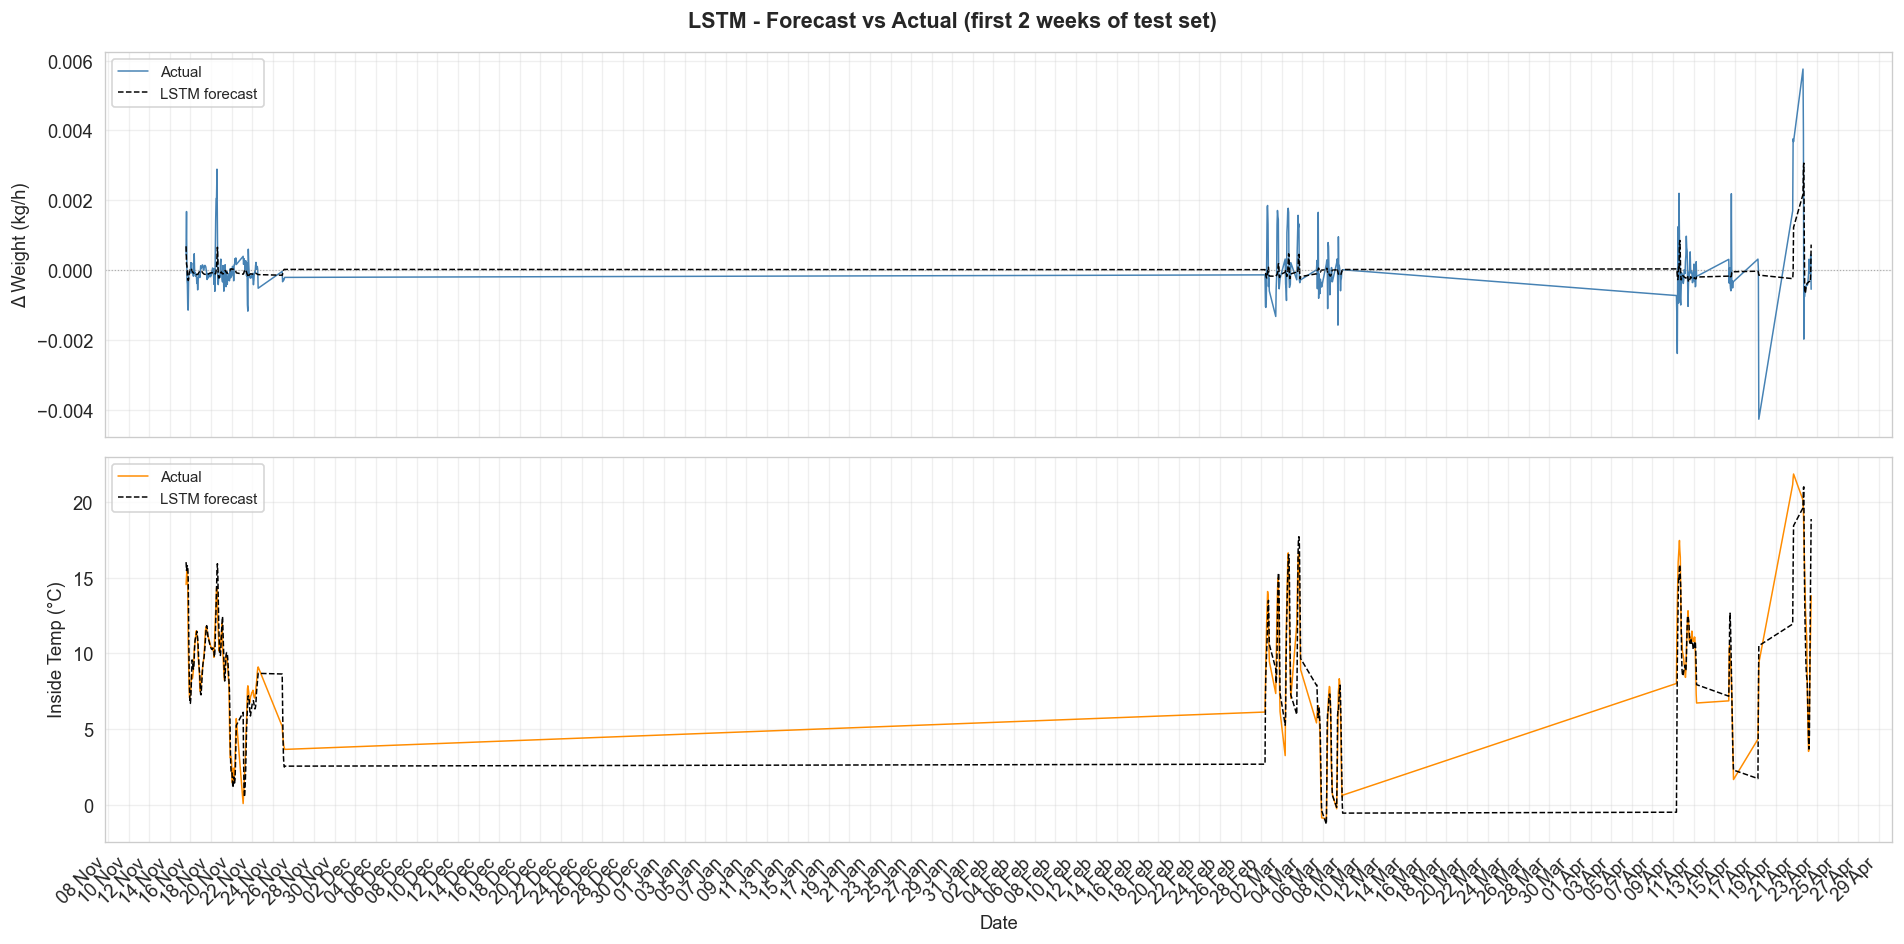

In [ ]:
# Generate predictions on test set
model.eval()
all_preds = []
with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        all_preds.append(model(X_batch).cpu().numpy())

y_pred_scaled = np.vstack(all_preds)

# Inverse-transform back to original scale
y_pred_orig = scaler_y.inverse_transform(y_pred_scaled)
y_test_orig = scaler_y.inverse_transform(y_te)

# Align with timestamps
n = min(len(y_pred_orig), len(lstm_test_idx))
lstm_pred_df = pd.DataFrame(y_pred_orig[:n], index=lstm_test_idx[:n], columns=LSTM_TARGETS)
lstm_test_df = pd.DataFrame(y_test_orig[:n], index=lstm_test_idx[:n], columns=LSTM_TARGETS)

print('=== LSTM ===')
lstm_metrics = []
for col in LSTM_TARGETS:
    m = eval_metrics(lstm_test_df[col], lstm_pred_df[col], 'LSTM', col)
    lstm_metrics.append(m)

# Plot - first 2 weeks
sample = 24 * 14
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
fig.suptitle('LSTM - Forecast vs Actual (first 2 weeks of test set)', fontsize=13, fontweight='bold')

plot_cfg = [
    ('weight_delta_noOutlier', 'Δ Weight (kg/h)', 'steelblue'),
    ('t_i_3', 'Inside Temp (°C)', 'darkorange'),
]
for ax, (col, ylabel, color) in zip(axes, plot_cfg):
    ax.plot(lstm_test_df.index[:sample], lstm_test_df[col].iloc[:sample], color=color, linewidth=0.9, label='Actual')
    ax.plot(lstm_pred_df.index[:sample], lstm_pred_df[col].iloc[:sample], color='black', linewidth=0.9, linestyle='--', label='LSTM forecast')
    if col == 'weight_delta_noOutlier':
        ax.axhline(0, color='grey', linestyle=':', linewidth=0.7, alpha=0.6)
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
axes[1].xaxis.set_major_locator(mdates.DayLocator(interval=2))
axes[1].set_xlabel('Date')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 8.5 Anomaly detection

LSTM anomalies:
  LSTM / weight_delta_noOutlier: 48 anomalies (2.30% of test set, threshold ±3.0σ)
  LSTM / t_i_3: 33 anomalies (1.58% of test set, threshold ±3.0σ)


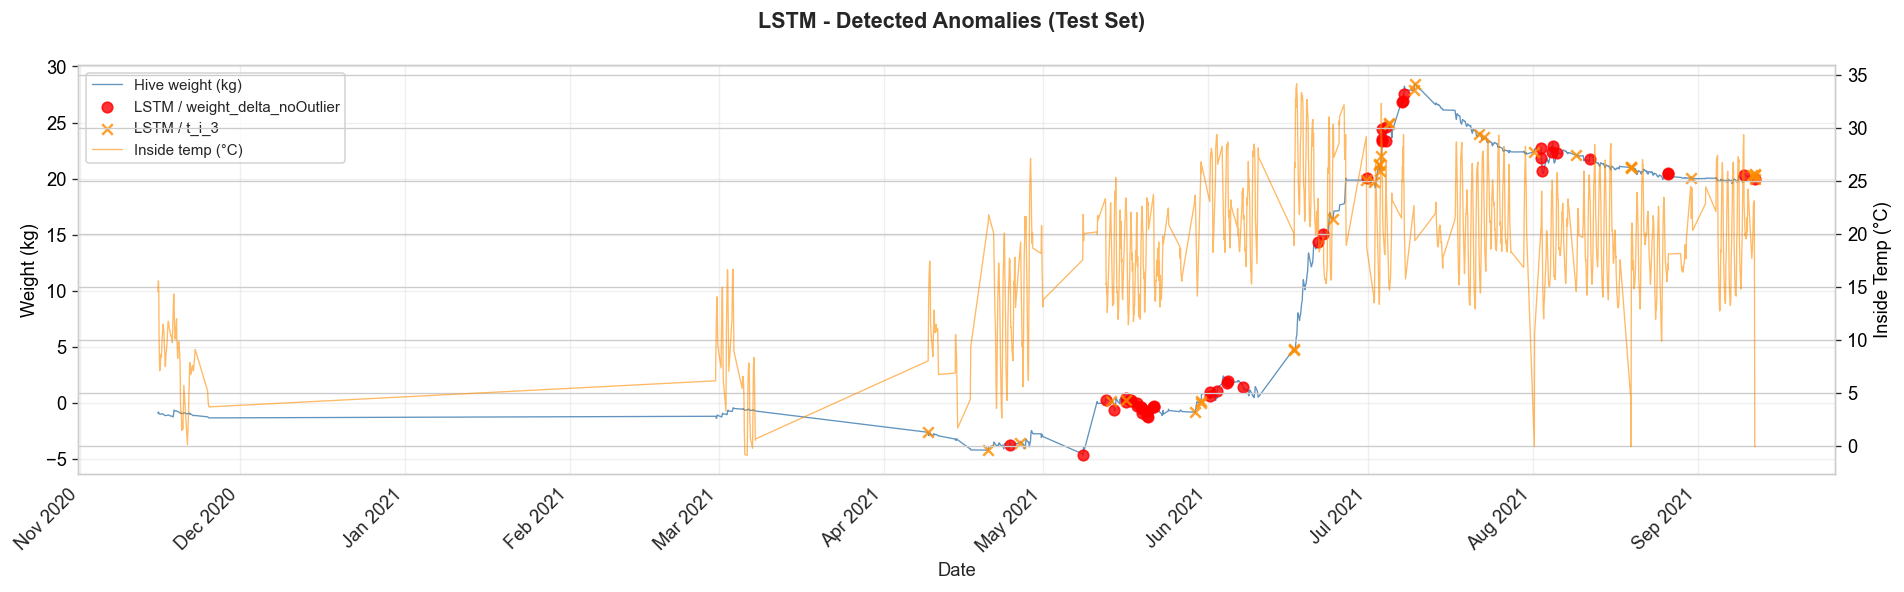

In [33]:
weight_lstm = df_all['weight_kg_noOutlier'].reindex(lstm_test_df.index)
temp_lstm = df_all['t_i_3'].reindex(lstm_test_df.index)

print('LSTM anomalies:')
lstm_anom = {}
for col in LSTM_TARGETS:
    anom = detect_anomalies(lstm_test_df[col], lstm_pred_df[col], 'LSTM', col)
    lstm_anom[f'LSTM / {col}'] = anom

plot_anomalies(weight_lstm, temp_lstm, lstm_anom, 'LSTM - Detected Anomalies (Test Set)')

### 9.6 Save model for Raspberry Pi deployment

In [35]:
# Save model architecture + weights as a full TorchScript model (no class definition needed on Pi)
scripted_model = torch.jit.script(model.cpu())
scripted_model.save('lstm_beehive.pt')
print(f'Model saved  : lstm_beehive.pt ({os.path.getsize("lstm_beehive.pt")/1024:.1f} KB)')

# Save scalers
with open('lstm_scaler_X.pkl', 'wb') as f: pickle.dump(scaler_X, f)
with open('lstm_scaler_y.pkl', 'wb') as f: pickle.dump(scaler_y, f)
print('Scalers saved: lstm_scaler_X.pkl, lstm_scaler_y.pkl')

Model saved  : lstm_beehive.pt (229.8 KB)
Scalers saved: lstm_scaler_X.pkl, lstm_scaler_y.pkl


## 9. Sources

- [BeeObserver on Zenodo](https://zenodo.org/records/10407693)
- [Discrete Time Series Forecasting in Non-Invasive Monitoring of Managed Honey Bee Colonies: Part II: Are Hive Weight and In-Hive Temperature Seasonal and Colony-Specific?](https://pmc.ncbi.nlm.nih.gov/articles/PMC12299814/)
- [Hive weight time series prediction using meteorological factors during R. Pseudoacaica nectar flow](https://www.emetsoc.org/wp-content/uploads/2025/09/EMS2025-OPA_EMS2025-16Csilla_Vincze-1.pdf)
- [Weight, temperature and humidity sensor data of honey bee colonies in Germany, 2019–2022](https://www.sciencedirect.com/science/article/pii/S2352340923010429)
- [How to Check if Time Series Data is Stationary with Python](https://machinelearningmastery.com/time-series-data-stationary-python/)
- [LightGBM documentation](https://lightgbm.readthedocs.io/)
- [LightGBM: A Highly Efficient Gradient Boosting Decision Tree](https://proceedings.neurips.cc/paper_files/paper/2017/file/6449f44a102fde848669bdd9eb6b76fa-Paper.pdf)
- [PyTorch documentation](https://pytorch.org/docs/stable/index.html)
- [PyTorch LSTM documentation](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html)
- [TorchScript documentation](https://pytorch.org/docs/stable/jit.html)
- [Understanding LSTM Networks](https://colah.github.io/posts/2015-08-Understanding-LSTMs/)
- [scikit-learn documentation](https://scikit-learn.org/stable/api/sklearn.metrics.html)
- [Pandas documentation](https://pandas.pydata.org/docs/reference/frame.html)
- [NumPy documentation](https://numpy.org/doc/)
- [Matplotlib documentation](https://matplotlib.org/stable/index.html)
- [Seaborn documentation](https://seaborn.pydata.org)
- [statsmodels documentation](https://www.statsmodels.org/stable/index.html)